## **Introduzione**

La seguente analisi è stata effettuata utilizzando un dataset che raccoglie i dati sui crimini registrati nella città di **Baltimora (Maryland, USA)** tra gli anni 2010 e 2017.
Il dataset contiene informazioni dettagliate su ogni evento criminale, tra cui **data, ora, tipologia di reato, localizzazione geografica, distretto di polizia e coordinate GPS**, coprendo un ampio periodo temporale.

L'obiettivo dell'analisi è quello di effettuare una clusterizzazione dei distretti di polizia basati sui loro profili di criminalità, utilizzando algoritmi di clustering come **K-Means**.

Per l'analisi verranno utilizzate librerie Python come **pandas, matplotlib, seaborn, numpy, scipy e sklearn**, che consentiranno di effettuare una **pulizia accurata dei dati, un'analisi esplorativa (EDA) e la modellazione del modello di clustering**.

**N.B.**: Per questioni di compatibilità con le versioni delle librerie, si consiglia di utilizzare la versione **3.12.4** di Python.

In [2]:
# Installazione dei pacchetti necessari
%pip install -r requirements.txt

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [1]:
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans, DBSCAN
from sklearn.preprocessing import LabelEncoder
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
from sklearn.neighbors import NearestNeighbors
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.cluster.hierarchy import linkage, dendrogram
import geopandas as gpd
import folium
from folium.plugins import FastMarkerCluster
from sklearn.cluster import MiniBatchKMeans
from sklearn.preprocessing import OneHotEncoder
from scipy.sparse import csr_matrix


### **Import del dataset**

Si inizia l'analisi importando il dataset in formato `.csv`, disponibile al seguente link ufficiale:
🔗 [City of Baltimore Crime Data](https://data.world/data-society/city-of-baltimore-crime-data)

Per avere una visualizzazione piu' dettagliata del dataset, si consiglia di visionare il file `timeseries.ipynb`, che contiene un'analisi delle feature del dataset.

### **Considerazioni preliminari**
Una prima analisi esplorativa (non mostrata qui) ha evidenziato la presenza di valori mancanti, colonne ridondanti e formati non uniformi (in particolare date, orari e coordinate geografiche).

**Caricamento e pulizia dei dati**
- Verranno rimosse le colonne non necessarie (`CrimeDate`, `Location`, `Neighborhood`, `Total Incidents`) e verranno rimosse righe con valori mancanti.
- La colonna `CrimeTime` (originariamente in formato H:M:S) verrà trasformata per estrarre solo l'ora. Quest'ultima verrà poi usata per creare una nuova colonna categorica, `HourBin`, che divide il giorno in quattro fasce: `Night`, `Morning`, `Afternoon` e `Evening`.
- Le coordinate di latitudine e longitudine verranno estratte dalla colonna `Location 1`, che verrà poi eliminata.
- I valori testuali nelle colonne `District` e `Description` verranno puliti, rimuovendo spazi e correggendo refusi.

In [2]:
# Lettura il dataset CSV
df = pd.read_csv("CrimeData.csv")

# Rimozione colonne non necessarie
df = df.drop(columns=['CrimeDate','Location', 'Neighborhood','Total Incidents'], axis=1)

# Conversione colonna "CrimeTime"
df['CrimeTime'] = pd.to_datetime(df['CrimeTime'], format='%H:%M:%S', errors='coerce').dt.hour

# Estrazione coordinate
df[['Latitude', 'Longitude']] = df['Location 1'].str.extract(r'\((.*), (.*)\)').astype(float)
df = df.drop(columns=['Location 1'])

# Uniformizzazione stringhe
df['Description'] = df['Description'].str.strip()
df['District'] = df['District'].str.strip().replace({
    'Central':'CENTRAL', 
    'NORTHESTERN':'NORTHEASTERN', 
    'SOUTHESTERN':'SOUTHEASTERN', 
    'Gay Street': 'EASTERN'
})
# Standardizzazione più chiara di Inside/Outside
io_map = {'I': 'Inside', 'Inside': 'Inside', 'O': 'Outside', 'Outside': 'Outside'}
df['Inside/Outside'] = df['Inside/Outside'].map(io_map)

# Creazione fasce orarie
bins  = [-0.1, 5, 11, 17, 23]
labs  = ['Night','Morning','Afternoon','Evening']
df['HourBin'] = pd.cut(df['CrimeTime'], bins=bins, labels=labs)

# Rimozione delle righe con valori nulli
df = df.dropna()

# Visualizzazione informazioni sul dataset dopo la pulizia
print("Totale righe dopo pulizia:", len(df))
df.head(10)

Totale righe dopo pulizia: 90865


,CrimeTime,CrimeCode,Description,Inside/Outside,Weapon,Post,District,Latitude,Longitude,HourBin
1,2.0,3CF,ROBBERY - COMMERCIAL,Inside,FIREARM,213.0,SOUTHEASTERN,39.28242,-76.59288,Night
5,3.0,4E,COMMON ASSAULT,Inside,HANDS,423.0,NORTHEASTERN,39.37070,-76.56709,Night
6,3.0,3CO,ROBBERY - COMMERCIAL,Outside,OTHER,933.0,SOUTHERN,39.28624,-76.64455,Night
9,8.0,4E,COMMON ASSAULT,Inside,HANDS,743.0,WESTERN,39.30340,-76.63842,Morning
11,9.0,4E,COMMON ASSAULT,Inside,HANDS,813.0,SOUTHWESTERN,39.30587,-76.67216,Morning
12,9.0,4E,COMMON ASSAULT,Inside,HANDS,312.0,EASTERN,39.29883,-76.61042,Morning
14,11.0,4E,COMMON ASSAULT,Inside,HANDS,444.0,NORTHEASTERN,39.32120,-76.53906,Morning
17,11.0,4B,AGG. ASSAULT,Outside,KNIFE,714.0,WESTERN,39.28810,-76.64888,Morning
19,0.0,3AF,ROBBERY - STREET,Outside,FIREARM,733.0,WESTERN,39.31249,-76.64539,Night
20,0.0,3AF,ROBBERY - STREET,Outside,FIREARM,733.0,WESTERN,39.31249,-76.64539,Night


## Clustering K-Means sui dati grezzi (senza filtraggio DBSCAN)

Dopo aver analizzato i cluster ottenuti applicando K-Means su un dataset preventivamente filtrato tramite DBSCAN, viene ora replicata **la stessa identica pipeline di clustering** direttamente sui **dati grezzi**, senza alcuna rimozione preliminare del rumore.

L’obiettivo di questa seconda analisi è duplice:
- valutare quanto il filtraggio con DBSCAN influenzi la struttura dei cluster individuati da K-Means;
- confrontare stabilità, interpretabilità e significato dei cluster ottenuti nei due scenari.

In questa fase:
- **non viene applicato DBSCAN**;
- tutti gli eventi di reato vengono considerati come input per K-Means;
- la procedura di preprocessing (label encoding e standardizzazione) rimane invariata, così da rendere il confronto metodologicamente corretto.

---

### Encoding delle variabili categoriche e standardizzazione

Le variabili categoriche (`Description`, `Weapon`, `HourBin`, `Inside/Outside`) vengono trasformate in valori numerici tramite **Label Encoding**, mentre tutte le feature vengono successivamente **standardizzate** con `StandardScaler`.

La standardizzazione è fondamentale per K-Means, poiché l’algoritmo si basa sulla distanza euclidea e richiede che tutte le feature contribuiscano in modo comparabile al calcolo delle distanze.

Il dataset risultante (`new_df`) rappresenta quindi lo spazio delle feature su cui verrà applicato direttamente l’algoritmo di clustering.


In [3]:
# Feature categoriche da labelizzare
categorical_cols = ['Description','Weapon','HourBin', 'Inside/Outside']

# Label encoding 
encoders = {}

for col in categorical_cols:
    le = LabelEncoder()
    df[f'{col}_encoded'] = le.fit_transform(df[col])
    encoders[col] = le

X = df[['Latitude', 'Longitude', 'Description_encoded', 'Weapon_encoded', 'HourBin_encoded', 'Inside/Outside_encoded']].values

# Standardizzazione delle feature
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

new_df = pd.DataFrame(X_scaled, columns=['Latitude', 'Longitude', 'Description_encoded', 'Weapon_encoded', 'HourBin_encoded', 'Inside/Outside_encoded'])

new_df.head()


,Latitude,Longitude,Description_encoded,Weapon_encoded,HourBin_encoded,Inside/Outside_encoded
0,-0.434186,0.588002,1.357808,-1.327207,1.501282,-0.913352
1,1.111905,1.208444,-0.246000,-0.245884,1.501282,-0.913352
2,-0.367285,-0.655045,1.357808,1.916761,1.501282,1.094868
3,-0.066753,-0.507573,-0.246000,-0.245884,0.601216,-0.913352
4,-0.023495,-1.319271,-0.246000,-0.245884,0.601216,-0.913352


### Scelta del numero ottimale di cluster per K-Means

Poiché K-Means richiede di specificare a priori il numero di cluster `K`, viene effettuata un’analisi preliminare per individuare il valore più appropriato utilizzando due metriche complementari:

- **Metodo Elbow (Inertia)**: misura la somma delle distanze quadratiche dei punti dal centroide del cluster di appartenenza.  
  Un valore ottimale di `K` è spesso associato a un “gomito” nella curva, oltre il quale la riduzione dell’inerzia diventa marginale.

- **Silhouette Score**: valuta quanto ogni punto è simile al proprio cluster rispetto agli altri.  
  Valori più alti indicano cluster più compatti e meglio separati.

L’analisi viene eseguita su un intervallo di valori di `K` compreso tra 2 e 7, utilizzando come input il dataset pulito ottenuto dopo DBSCAN.


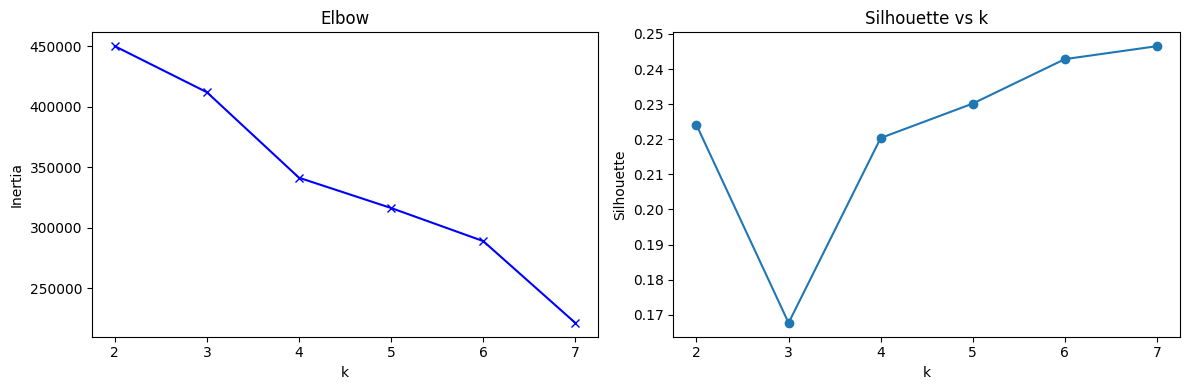

In [4]:
# Elbow Method per determinare il valore ottimale di k
distorsions = []
silhouettes = []
K = range(2, 8)

for k in K:
    km = KMeans(n_clusters=k, n_init='auto', random_state=0)
    labels = km.fit_predict(new_df)
    distorsions.append(km.inertia_)
    silhouettes.append(silhouette_score(new_df, labels))

plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(K, distorsions, 'bx-')
plt.xlabel('k'); plt.ylabel('Inertia'); plt.title('Elbow')

plt.subplot(1,2,2)
plt.plot(K, silhouettes, 'o-')
plt.xlabel('k'); plt.ylabel('Silhouette'); plt.title('Silhouette vs k')
plt.tight_layout(); plt.show()

#### Metodo Elbow

Dal grafico dell’inerzia si osserva una **riduzione molto marcata passando da K=2 a K=4**.  
Oltre questo valore, il miglioramento diventa progressivamente più contenuto, indicando un **punto di flesso attorno a K=4**.

Questo suggerisce che:
- l’aumento del numero di cluster oltre K=4 non porta a una significativa riduzione della variabilità interna;
- K=4 rappresenta un buon compromesso tra semplicità del modello e qualità del clustering.

---

#### Silhouette Score

Il Silhouette Score mostra:
- un valore relativamente alto per **K=2**;
- un calo evidente per **K=3**, indice di una partizione poco stabile;
- una **crescita progressiva a partire da K=4**, con valori via via migliori fino a K=7.

Tuttavia, l’aumento del Silhouette Score oltre K=4 risulta **graduale** e non accompagnato da un chiaro miglioramento strutturale osservabile nel metodo Elbow.

---

#### Considerazioni conclusive sulla scelta di K

Combinando i due criteri, **K=4 emerge come la scelta più bilanciata**, in quanto:
- coincide con il punto di flesso più evidente nel grafico Elbow;
- rappresenta il primo valore di K per cui il Silhouette Score torna a crescere in modo stabile;
- evita una frammentazione eccessiva del dataset in cluster molto piccoli.

Si osserva inoltre che la scelta di **K=4 è coerente** con quanto emerso nell’analisi precedente basata sul dataset filtrato tramite DBSCAN, suggerendo una **buona robustezza della struttura dei cluster** anche in assenza di rimozione preventiva del rumore.

> **Nota**
Valori di K maggiori (es. K=5–7) mostrano silhouette leggermente superiori, ma al costo di una maggiore complessità interpretativa e senza un chiaro vantaggio strutturale

### Esecuzione di K-Means sui dati grezzi

Dopo aver determinato il valore ottimale di `K` tramite Elbow e Silhouette, si esegue ora il clustering **K-Means con K = 4**.

In questa fase:
- ogni evento viene assegnato a uno dei 4 cluster individuati da K-Means;
- le etichette risultanti vengono aggiunte al dataset originale (`df`) in una nuova colonna (`event_cluster`).

L’obiettivo è ottenere una partizione globale degli eventi, così da interpretare i profili dei cluster.


In [15]:
# === Fit KMeans e assegnazione agli eventi ===
k_opt1 = 4
kmeans = KMeans(n_clusters=k_opt1, n_init='auto', random_state=0)
labels = kmeans.fit_predict(new_df)

df_kmeans = df.copy()
df_kmeans['event_cluster'] = labels
# Conteggio dei valori per ogni cluster
print(df_kmeans['event_cluster'].value_counts().sort_index())
df_kmeans.head(10)

event_cluster
0    21124
1    30826
2    24786
3    14129
Name: count, dtype: int64


,CrimeTime,CrimeCode,Description,Inside/Outside,Weapon,Post,District,Latitude,Longitude,HourBin,Description_encoded,Weapon_encoded,HourBin_encoded,Inside/Outside_encoded,event_cluster
1,2.0,3CF,ROBBERY - COMMERCIAL,Inside,FIREARM,213.0,SOUTHEASTERN,39.28242,-76.59288,Night,4,0,3,0,3
5,3.0,4E,COMMON ASSAULT,Inside,HANDS,423.0,NORTHEASTERN,39.37070,-76.56709,Night,1,1,3,0,2
6,3.0,3CO,ROBBERY - COMMERCIAL,Outside,OTHER,933.0,SOUTHERN,39.28624,-76.64455,Night,4,3,3,1,1
9,8.0,4E,COMMON ASSAULT,Inside,HANDS,743.0,WESTERN,39.30340,-76.63842,Morning,1,1,2,0,0
11,9.0,4E,COMMON ASSAULT,Inside,HANDS,813.0,SOUTHWESTERN,39.30587,-76.67216,Morning,1,1,2,0,0
12,9.0,4E,COMMON ASSAULT,Inside,HANDS,312.0,EASTERN,39.29883,-76.61042,Morning,1,1,2,0,2
14,11.0,4E,COMMON ASSAULT,Inside,HANDS,444.0,NORTHEASTERN,39.32120,-76.53906,Morning,1,1,2,0,2
17,11.0,4B,AGG. ASSAULT,Outside,KNIFE,714.0,WESTERN,39.28810,-76.64888,Morning,0,2,2,1,1
19,0.0,3AF,ROBBERY - STREET,Outside,FIREARM,733.0,WESTERN,39.31249,-76.64539,Night,6,0,3,1,3
20,0.0,3AF,ROBBERY - STREET,Outside,FIREARM,733.0,WESTERN,39.31249,-76.64539,Night,6,0,3,1,3


#### Distribuzione degli eventi per cluster

Il numero di eventi assegnati a ciascun cluster è il seguente:

- **Cluster 0**: 21.124 eventi  
- **Cluster 1**: 30.826 eventi  
- **Cluster 2**: 24.786 eventi  
- **Cluster 3**: 14.129 eventi  

La distribuzione risulta **non perfettamente uniforme**, ma comunque priva di cluster estremamente piccoli o residuali. Tutti i cluster contengono una quota significativa di eventi, indicando che K-Means ha suddiviso il dataset in gruppi strutturalmente rilevanti.

---

#### Interpretazione

L’assenza di cluster molto ridotti suggerisce che:
- il clustering sui dati grezzi tende a **modellare le macro-differenze** presenti nel dataset;
- eventi meno frequenti o atipici vengono comunque assegnati a un cluster esistente, anziché essere isolati.

Questo comportamento è coerente con la natura di K-Means, che **non prevede l’identificazione esplicita del rumore o degli outlier**, ma forza ogni osservazione ad appartenere a uno dei cluster.

Questa osservazione diventa particolarmente rilevante nel confronto con l’analisi che include DBSCAN, dove una parte degli eventi viene invece esclusa come rumore prima dell’applicazione di K-Means.

### Visualizzazione e interpretazione dei cluster tramite PCA

Per supportare l’interpretazione dei cluster ottenuti con K-Means, viene applicata la **Principal Component Analysis (PCA)** al dataset standardizzato(`new_df`).

La PCA consente di:
- ridurre la dimensionalità dei dati,
- proiettare gli eventi in uno spazio a 2 dimensioni,
- analizzare quali variabili contribuiscono maggiormente alla separazione dei cluster.

È importante sottolineare che la PCA **non viene utilizzata per il clustering**, ma esclusivamente come strumento di analisi e interpretazione dei risultati prodotti da K-Means.

In questa analisi viene mostrata la proiezione sulle **prime due componenti principali**, che spiegano la quota maggiore di varianza complessiva.


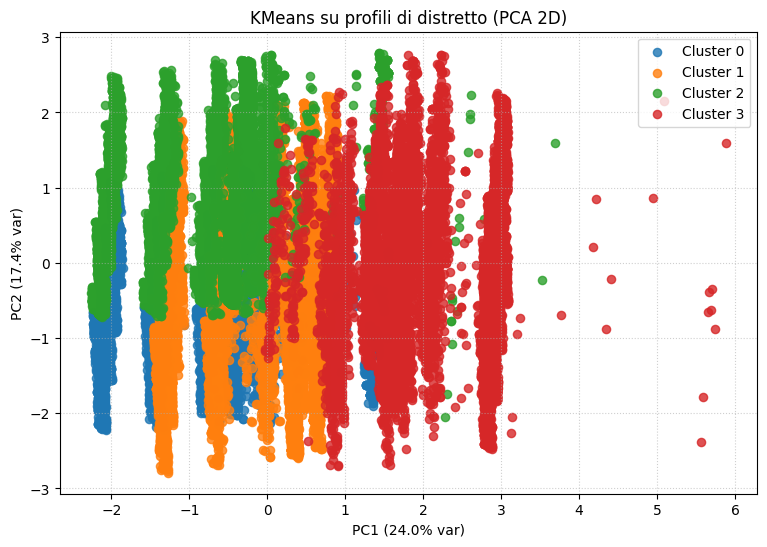

=== PC1 (24.0%) - Cosa sposta i punti a destra/sinistra? ===
--- Spingono a DESTRA (Valori Alti) ---
Description_encoded       0.681584
Inside/Outside_encoded    0.395248
HourBin_encoded           0.075891
Latitude                  0.071248
Longitude                -0.004860
Name: PC1, dtype: float64

--- Spingono a SINISTRA (Valori Bassi) ---
Weapon_encoded           -0.606929
Longitude                -0.004860
Latitude                  0.071248
HourBin_encoded           0.075891
Inside/Outside_encoded    0.395248
Name: PC1, dtype: float64

=== PC2 (17.4%) - Cosa sposta i punti in alto/basso? ===
--- Spingono in ALTO (Valori Alti) ---
HourBin_encoded        0.710839
Longitude              0.638312
Description_encoded    0.001943
Latitude              -0.013449
Weapon_encoded        -0.097095
Name: PC2, dtype: float64

--- Spingono in BASSO (Valori Bassi) ---
Inside/Outside_encoded   -0.278662
Weapon_encoded           -0.097095
Latitude                 -0.013449
Description_encoded    

In [16]:
# === PCA per visualizzare in 2D ===
pca = PCA(n_components=2, random_state=0)
X_pca = pca.fit_transform(new_df)

plt.figure(figsize=(9,6))
for c in np.unique(labels):
    plt.scatter(
        X_pca[labels == c, 0],
        X_pca[labels == c, 1],
        s=35,
        alpha=0.8,
        label=f'Cluster {c}')

plt.title('KMeans su profili di distretto (PCA 2D)')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% var)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% var)')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

# Crea un DataFrame dei 'loadings' (pesi)
loadings = pd.DataFrame(
    pca.components_.T,  # .T per avere le feature come righe
    columns=['PC1', 'PC2'],
    index=new_df.columns
)

# Stampa le feature più influenti per PC1 (Asse X)
print(f"=== PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%) - Cosa sposta i punti a destra/sinistra? ===")
print("--- Spingono a DESTRA (Valori Alti) ---")
print(loadings['PC1'].sort_values(ascending=False).head(5))
print("\n--- Spingono a SINISTRA (Valori Bassi) ---")
print(loadings['PC1'].sort_values(ascending=True).head(5))

# Stampa le feature più influenti per PC2 (Asse Y)
print(f"\n=== PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%) - Cosa sposta i punti in alto/basso? ===")
print("--- Spingono in ALTO (Valori Alti) ---")
print(loadings['PC2'].sort_values(ascending=False).head(5))
print("\n--- Spingono in BASSO (Valori Bassi) ---")
print(loadings['PC2'].sort_values(ascending=True).head(5))

#### Interpretazione delle Componenti Principali (PCA)

Per interpretare in modo più rigoroso la proiezione PCA, vengono analizzati i **loadings**, ovvero i pesi con cui ciascuna variabile contribuisce alla formazione delle componenti principali.

---

##### PC1 — Prima Componente Principale (24.0% della varianza)

La prima componente principale è fortemente guidata da:

- **Valori positivi (spostamento verso destra)**:
  - `Description_encoded` (**0.68**)
  - `Inside/Outside_encoded` (**0.40**)

- **Valori negativi (spostamento verso sinistra)**:
  - `Weapon_encoded` (**−0.61**)

Questa componente separa quindi gli eventi principalmente in base a:
- **tipologia di reato**,
- **contesto dell’evento (interno vs esterno)**,
- **presenza e tipologia di arma**.

In particolare:
- a destra del grafico si collocano eventi differenziati soprattutto per **tipo di reato** e **luogo dell’evento**;
- a sinistra prevalgono eventi caratterizzati maggiormente dalla **tipologia di arma utilizzata**.

La posizione geografica (latitudine e longitudine) ha un impatto marginale su PC1.

---

##### PC2 — Seconda Componente Principale (17.4% della varianza)

La seconda componente è dominata da:

- **Valori positivi (spostamento verso l’alto)**:
  - `HourBin_encoded` (**0.71**)
  - `Longitude` (**0.64**)

- **Valori negativi (spostamento verso il basso)**:
  - `Inside/Outside_encoded` (**−0.28**)

Questa componente descrive principalmente una separazione basata su:
- **fascia oraria del crimine**,
- **localizzazione longitudinale (asse Est–Ovest)**,
- in misura minore sul **contesto interno/esterno**.

Gli eventi più in alto nel grafico sono quindi associati a:
- specifiche fasce orarie (giorno/notte),
- determinate aree della città lungo l’asse longitudinale.

---

##### Considerazioni complessive sulla PCA

Nel complesso:
- PC1 cattura differenze **strutturali e semantiche** (tipo di reato, arma, luogo);
- PC2 cattura differenze **temporali e spaziali**.

La forte influenza delle variabili categoriche (label-encodate) spiega la presenza di **strutture a bande** e la limitata separazione visiva dei cluster nel piano PCA.

È importante sottolineare che:
- la PCA **non è ottimizzata per separare i cluster**, ma per preservare la varianza globale;
- la sovrapposizione osservata non indica una scarsa qualità del clustering;
- l’interpretazione dei cluster deve basarsi principalmente su:
  - profili medi (one-hot encoding),
  - heatmap,
  - e soprattutto sull’analisi del **Lift**, che evidenzia le caratteristiche distintive relative di ciascun cluster.

La PCA va quindi intesa come **strumento di supporto interpretativo**, non come criterio decisionale per la bontà del clustering.


### Costruzione dei profili dei cluster

I cluster ottenuti con K-Means sono stati calcolati utilizzando feature numeriche (coordinate + variabili categoriche codificate e standardizzate).  
Tuttavia, per interpretare **il significato reale dei cluster** è necessario tornare a variabili leggibili e confrontabili, come le categorie originali di:

- tipo di reato (`Description`)
- arma (`Weapon`)
- fascia oraria (`HourBin`)
- contesto (`Inside/Outside`)

In questa fase si procede quindi a:

1. eliminare le colonne `_encoded` (utili solo per il clustering numerico);
2. applicare il **One-Hot Encoding** alle colonne categoriche originali;
3. ottenere una rappresentazione binaria (0/1) per ogni categoria, che consente poi di calcolare facilmente **frequenze/percentuali** per cluster.

L’obiettivo è preparare i dati per calcolare, in seguito, la **media per cluster** delle colonne one-hot: tale media corrisponderà alla percentuale di eventi del cluster che appartiene a ciascuna categoria (profilo del cluster).


In [10]:
# Pulizia del dataframe finale con i cluster di Kmeans
# elimino le colonne _encoded e la colonna cluster
cleaned_clustered_values = df_kmeans.drop(columns=['Description_encoded', 'Weapon_encoded', 'HourBin_encoded', 'Inside/Outside_encoded'])

# Categorie per fare il profilo
cat_cols = ['Description','Weapon','HourBin', 'Inside/Outside']

# One-hot encoding (dummies)
dummies = pd.get_dummies(cleaned_clustered_values[cat_cols], drop_first=False)

# Concatenazione dei dummies al dataframe pulito
cleaned_clustered_values = pd.concat([cleaned_clustered_values['event_cluster'].reset_index(drop=True), dummies.reset_index(drop=True)], axis=1)

cleaned_clustered_values.head(10)


,event_cluster,Description_AGG. ASSAULT,Description_COMMON ASSAULT,Description_RAPE,Description_ROBBERY - CARJACKING,Description_ROBBERY - COMMERCIAL,Description_ROBBERY - RESIDENCE,Description_ROBBERY - STREET,Weapon_FIREARM,Weapon_HANDS,Weapon_KNIFE,Weapon_OTHER,HourBin_Night,HourBin_Morning,HourBin_Afternoon,HourBin_Evening,Inside/Outside_Inside,Inside/Outside_Outside
0,3,False,False,False,False,True,False,False,True,False,False,False,True,False,False,False,True,False
1,2,False,True,False,False,False,False,False,False,True,False,False,True,False,False,False,True,False
2,1,False,False,False,False,True,False,False,False,False,False,True,True,False,False,False,False,True
3,0,False,True,False,False,False,False,False,False,True,False,False,False,True,False,False,True,False
4,0,False,True,False,False,False,False,False,False,True,False,False,False,True,False,False,True,False
5,2,False,True,False,False,False,False,False,False,True,False,False,False,True,False,False,True,False
6,2,False,True,False,False,False,False,False,False,True,False,False,False,True,False,False,True,False
7,1,True,False,False,False,False,False,False,False,False,True,False,False,True,False,False,False,True
8,3,False,False,False,False,False,False,True,True,False,False,False,True,False,False,False,False,True
9,3,False,False,False,False,False,False,True,True,False,False,False,True,False,False,False,False,True


A questo punto il dataset contiene:
- la colonna `event_cluster`,
- e un insieme di colonne binarie ottenute dal One-Hot Encoding.

Ogni riga rappresenta un evento; le colonne one-hot valgono 1 se l’evento appartiene a quella categoria, altrimenti 0.

Il passo successivo consiste nel **raggruppare per `event_cluster` e calcolare la media** delle colonne one-hot:  
la media di una colonna binaria corrisponde alla **percentuale** di eventi del cluster che appartiene a quella categoria, ottenendo così un **profilo interpretabile del cluster**.


### Creazione dei profili percentuali dei cluster

Dopo aver trasformato le variabili categoriche in colonne binarie tramite **One-Hot Encoding**, è possibile costruire un profilo sintetico per ciascun cluster K-Means.

Il principio è semplice:  
poiché ogni colonna one-hot vale **1** se l’evento appartiene a quella categoria e **0** altrimenti, la **media** di quella colonna all’interno di un cluster corrisponde alla **percentuale di eventi** del cluster che appartiene a quella categoria.

Esempio:
- se in un cluster la colonna `Weapon_HANDS` ha media `0.77`, significa che **il 77% degli eventi** di quel cluster coinvolge “Hands”.

Per ottenere questi profili, si raggruppano i dati per `event_cluster` e si calcola la media delle colonne binarie.


In [12]:
# Aggrego per cluster calcolando i profili percentuali

# Unità di aggregazione: Cluster
profile = cleaned_clustered_values.groupby('event_cluster', as_index=True).mean()

print(profile.round(3))

               Description_AGG. ASSAULT  Description_COMMON ASSAULT  \
event_cluster                                                         
0                                 0.316                       0.630   
1                                 0.440                       0.543   
2                                 0.280                       0.669   
3                                 0.000                       0.000   

               Description_RAPE  Description_ROBBERY - CARJACKING  \
event_cluster                                                       
0                         0.027                             0.001   
1                         0.011                             0.004   
2                         0.022                             0.001   
3                         0.000                             0.058   

               Description_ROBBERY - COMMERCIAL  \
event_cluster                                     
0                                         0.019   
1    

### Interpretazione dei profili dei cluster (percentuali)

La tabella risultante descrive, per ciascun cluster, la distribuzione percentuale delle categorie principali (tipo di reato, arma, fascia oraria e contesto Inside/Outside).  
Dall’output emergono profili molto distinti:

#### Cluster 0 — Crimini comuni in contesti interni

Il **Cluster 0** è caratterizzato principalmente da:
- un’alta incidenza di **COMMON ASSAULT** (63%) e **AGG. ASSAULT** (31%);
- un uso prevalente di **mani come arma** (`Weapon_HANDS`, 68%);
- eventi che avvengono **quasi esclusivamente all’interno** (`Inside = 100%`).

La distribuzione temporale è abbastanza uniforme, con una leggera prevalenza delle fasce **pomeridiane e serali**.

Questo cluster rappresenta quindi **crimini frequenti e relativamente meno specializzati**, che costituiscono una parte consistente del dataset complessivo.

---

#### Cluster 1 — Crimini comuni in contesti esterni

Il **Cluster 1** mostra un profilo simile al Cluster 0 per tipologia di reato, ma con una differenza fondamentale:
- gli eventi avvengono **esclusivamente all’esterno** (`Outside = 100%`);
- permane una forte presenza di **COMMON ASSAULT** (54%) e **AGG. ASSAULT** (44%);
- l’uso delle armi è più variegato, con una presenza leggermente maggiore di **armi da fuoco** (12%).

Questo cluster può essere interpretato come l’equivalente *crimini in esterna* del Cluster 0.

---

#### Cluster 2 — Crimini comuni interni con maggiore incidenza notturna

Il **Cluster 2** è ancora dominato da:
- **COMMON ASSAULT** (67%) e **AGG. ASSAULT** (28%);
- utilizzo quasi esclusivo di **mani come arma** (72%);
- eventi che avvengono **interamente all’interno**.

Rispetto ai cluster 0 e 1, presenta:
- una **maggiore incidenza notturna** (26%);
- una distribuzione temporale leggermente più spostata verso la notte.

Anche questo cluster rappresenta una **variazione di un profilo molto comune**, più che un pattern fortemente distintivo.

---

#### Cluster 3 — Crimini violenti e rapine

Il **Cluster 3** è nettamente diverso dagli altri ed emerge come il cluster più specializzato:
- altissima incidenza di **ROBBERY - STREET** (72%) e **ROBBERY - COMMERCIAL** (14%);
- uso massiccio di **armi da fuoco** (`Weapon_FIREARM`, 79%);
- eventi prevalentemente **all’esterno** (74%);
- maggiore concentrazione nelle fasce **serali e notturne**.

Questo cluster rappresenta chiaramente i **crimini più gravi e violenti**, distinguendosi in modo netto dal resto del dataset.

---

#### Considerazioni complessive

L’analisi dei profili mostra che, senza una fase di filtraggio del rumore:
- i cluster tendono a essere fortemente influenzati dalle **classi più frequenti** del dataset (COMMON ASSAULT, Weapon_HANDS);
- solo uno dei cluster (Cluster 3) emerge come **realmente distintivo**;
- gli altri cluster rappresentano variazioni relativamente sottili di uno stesso comportamento criminale di base.

Questo risultato evidenzia un limite del clustering diretto sui dati grezzi:
> **le strutture più rare ma informative vengono “schiacciate” dalla frequenza globale delle categorie dominanti**.

Nel confronto successivo con l’analisi che include una fase preliminare di DBSCAN, si osserverà come la rimozione del rumore consenta di ottenere cluster più caratterizzati e interpretabili.

### Analisi descrittiva dei cluster tramite heatmap dei profili percentuali

La heatmap consente di:
- confrontare visivamente i cluster tra loro,
- individuare rapidamente le feature **più frequenti** all’interno di ciascun gruppo,
- ottenere una prima intuizione sulle differenze strutturali tra i cluster.

È importante sottolineare che questa analisi riflette **le frequenze assolute** delle variabili, senza tenere conto della loro rarità o diffusione nel dataset complessivo.


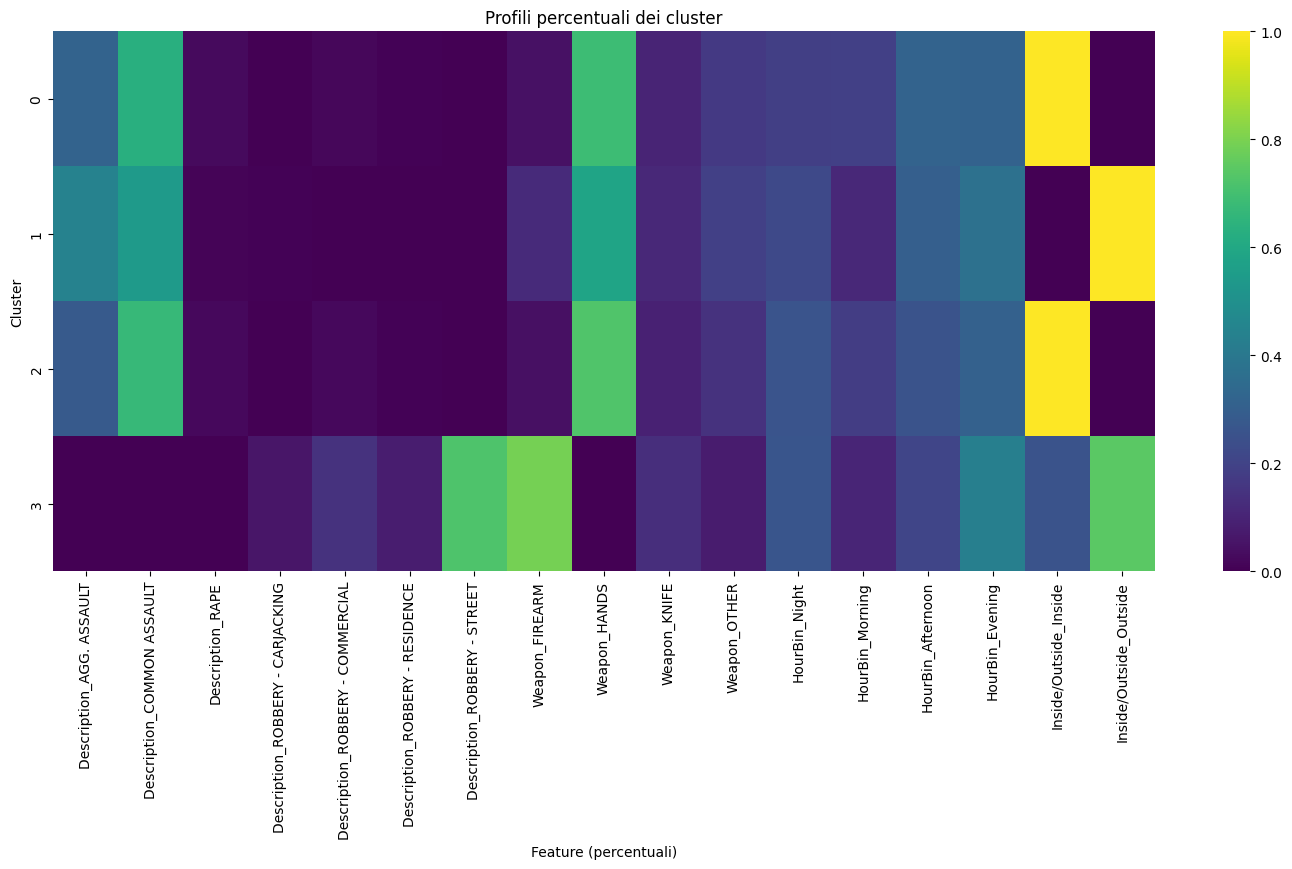

In [17]:
# === Heatmap dei centroidi per confronto rapido ===
plt.figure(figsize=(min(16, 0.5*len(profile.columns)+6), 1.2*k_opt1+4))
sns.heatmap(
    profile,
    cmap='viridis',
    annot=False,
    cbar=True
)
plt.title('Profili percentuali dei cluster')
plt.xlabel('Feature (percentuali)')
plt.ylabel('Cluster')
plt.tight_layout()
plt.show()

#### Pattern comuni tra i cluster

Dalla heatmap emerge subito che:
- **COMMON ASSAULT** e **Weapon_HANDS** risultano elevate in **più cluster**;
- le fasce orarie **Afternoon** ed **Evening** mostrano valori simili tra diversi cluster;
- molte feature rare (RAPE, CARJACKING, ROBBERY - COMMERCIAL) appaiono con colori molto scuri nella maggior parte dei cluster.

Questo indica che la struttura dei cluster è fortemente influenzata dalla **distribuzione globale del dataset**, dominata da eventi frequenti e ripetitivi.

---

#### Differenze tra i cluster

Nonostante l’omogeneità generale, alcune differenze sono comunque visibili:

- **Cluster 0 e Cluster 2**  
  Presentano profili molto simili:
  - alta incidenza di **COMMON ASSAULT**;
  - uso prevalente di **mani come armi**;
  - eventi che avvengono **quasi esclusivamente all’interno**.

  Questi cluster rappresentano variazioni dello stesso comportamento criminale di base.

- **Cluster 1**  
  Si distingue principalmente per:
  - eventi che avvengono **esclusivamente all’esterno**;
  - una distribuzione delle armi più variegata, con una maggiore presenza di **armi da fuoco** rispetto ai cluster 0 e 2.

- **Cluster 3**  
  È il cluster più chiaramente distinguibile:
  - forte presenza di **ROBBERY - STREET** e **ROBBERY - COMMERCIAL**;
  - uso dominante di **Weapon_FIREARM**;
  - maggiore concentrazione nelle fasce **Evening** e **Night**;
  - prevalenza di eventi **all’esterno**.

  Questo cluster rappresenta il gruppo di **crimini più violenti e specializzati**.

---

#### Limiti dell’interpretazione visiva

La heatmap evidenzia bene le **feature più frequenti**, ma tende a:
- enfatizzare le categorie dominanti del dataset;
- nascondere le differenze relative legate a eventi meno comuni ma informativamente rilevanti.

Di conseguenza, alcuni cluster risultano visivamente simili, pur avendo sfumature comportamentali diverse.

---

#### Collegamento con l’analisi del Lift

Per superare questi limiti, l’analisi del **Lift** diventa fondamentale:
- consente di valutare **quanto una feature è sovra- o sotto-rappresentata** rispetto alla media globale;
- permette di evidenziare caratteristiche distintive anche quando le percentuali assolute sono basse.

Nel confronto con l’analisi che include il filtraggio DBSCAN, si osserverà come la rimozione del rumore renda la heatmap un po' più leggibile e i cluster più nettamente caratterizzati.

### Analisi del Lift: individuazione delle caratteristiche distintive dei cluster

L’analisi basata sulle percentuali (medie delle colonne one-hot) permette di comprendere quali categorie sono più frequenti all’interno di ciascun cluster. Tuttavia, questo approccio presenta un limite importante:  
le categorie molto comuni a livello globale tendono a dominare la rappresentazione, mentre eventi meno frequenti ma altamente caratterizzanti rischiano di essere sottovalutati.

Per superare questo limite, viene introdotta l’**analisi del Lift**.

Il Lift confronta, per ogni feature e per ogni cluster, la sua incidenza nel cluster rispetto alla **media globale dell’intero dataset**. In questo modo è possibile identificare non solo ciò che è frequente, ma soprattutto ciò che è **sovra-rappresentato** in un cluster rispetto al comportamento medio complessivo.

Formalmente:
- **Lift > 1** indica che una feature è più presente nel cluster rispetto alla media globale;
- **Lift = 1** indica una presenza in linea con la media;
- **Lift < 1** indica una sotto-rappresentazione.

Questa analisi consente di assegnare una “firma” chiara a ciascun cluster, evidenziandone le peculiarità reali.


In [19]:
# === LIFT rispetto alla media globale ===
global_mean = profile.mean()

lift = profile.copy()
for col in lift.columns:
    baseline = global_mean[col] if global_mean[col] != 0 else 1e-9
    lift[col] = lift[col] / baseline  # >1 = sopra la media globale

for c in lift.index:
    print(f'\n=== {c}: feature con lift più alto ===')
    print(
        lift.loc[c]
        .sort_values(ascending=False)
        .head(15)
        .round(2))


=== 0: feature con lift più alto ===
Description_RAPE                    1.78
Inside/Outside_Inside               1.77
Weapon_HANDS                        1.38
Description_COMMON ASSAULT          1.37
HourBin_Morning                     1.30
Description_AGG. ASSAULT            1.22
HourBin_Afternoon                   1.17
Weapon_OTHER                        1.17
Weapon_KNIFE                        0.92
HourBin_Evening                     0.88
HourBin_Night                       0.80
Description_ROBBERY - COMMERCIAL    0.41
Description_ROBBERY - RESIDENCE     0.29
Weapon_FIREARM                      0.18
Description_ROBBERY - CARJACKING    0.05
Name: 0, dtype: float64

=== 1: feature con lift più alto ===
Inside/Outside_Outside              2.29
Description_AGG. ASSAULT            1.70
Weapon_OTHER                        1.30
Description_COMMON ASSAULT          1.18
Weapon_HANDS                        1.17
HourBin_Afternoon                   1.11
HourBin_Evening                     1.0

### Interpretazione dell’analisi del Lift

L’analisi del **Lift** consente di interpretare i cluster andando oltre le percentuali assolute, evidenziando **quali caratteristiche risultano sovra- o sotto-rappresentate rispetto alla media globale del dataset**.

Questa lettura è particolarmente importante nel caso in cui si utilizzi l’intero dataset senza una fase di filtraggio preliminare, poiché la distribuzione complessiva dei dati tende a essere dominata dagli eventi più frequenti.

---
#### Cluster 0 — Eventi **interni**, più diurni, con violenza “non armata”
Le feature più distintive del **Cluster 0** sono:
- `Inside/Outside_Inside` **1.77×** → eventi più spesso **al chiuso**
- `Weapon_HANDS` **1.38×** e `Description_COMMON ASSAULT` **1.37×** → aggressioni/violenza fisica senza arma
- `HourBin_Morning` **1.30×** e `HourBin_Afternoon` **1.17×** → più presenti **di mattina/pomeriggio**
- `Description_AGG. ASSAULT` **1.22×** → anche aggressioni aggravate più della media
- Nota: `Description_RAPE` **1.78×** risulta sovra-rappresentata rispetto alla media (pur essendo spesso rara in valore assoluto)

Le rapine e le armi da fuoco sono invece molto sotto la media:
- `Weapon_FIREARM` **0.18×**, `ROBBERY - COMMERCIAL` **0.41×**, `ROBBERY - CARJACKING` **0.05×**

**Sintesi**: cluster orientato a episodi interni e “fisici” (mani), più diurni; rapine e armi da fuoco quasi assenti.

---

#### Cluster 1 — Eventi **all’esterno**, con aggressioni aggravate
Il **Cluster 1** è fortemente marcato da:
- `Inside/Outside_Outside` **2.29×** → eventi molto più spesso **all’aperto**
- `Description_AGG. ASSAULT` **1.70×** → aggressioni aggravate sopra la media
- `Weapon_OTHER` **1.30×** → più frequenti “altre armi/strumenti” (categoria residuale)
- `Weapon_KNIFE` **1.02×** → coltelli sostanzialmente in linea / leggermente sopra
- Fasce orarie: `HourBin_Afternoon` **1.11×** e `HourBin_Evening` **1.04×** → lieve spinta verso pomeriggio/sera

Le rapine risultano molto sotto la media:
- `ROBBERY - COMMERCIAL` **0.03×**, `ROBBERY - CARJACKING` **0.25×**, `ROBBERY - RESIDENCE` **0.00×**

**Sintesi**: cluster “esterno” con **aggressioni aggravate** e maggiore presenza di armi/mezzi eterogenei (“other”), ma **non** orientato alle rapine.

---

#### Cluster 2 — Eventi **interni**, con COMMON ASSAULT e maggiore presenza notturna
Il **Cluster 2** condivide il tratto “interno” con il Cluster 0, ma con sfumature diverse:
- `Inside/Outside_Inside` **1.77×** → ancora fortemente **al chiuso**
- `Description_COMMON ASSAULT` **1.45×** e `Weapon_HANDS` **1.45×** → profilo molto “hands + common assault”
- Orario: `HourBin_Morning` **1.22×** ma anche `HourBin_Night` **1.12×** → rispetto al Cluster 0 compare una componente più “notturna”
- `Description_RAPE` **1.46×** → sopra media
- `Description_AGG. ASSAULT` **1.08×** → leggermente sopra media

Anche qui rapine e armi da fuoco sono sotto media:
- `Weapon_FIREARM` **0.17×**, `ROBBERY - COMMERCIAL` **0.47×**, `ROBBERY - CARJACKING` **0.06×**

**Sintesi**: cluster interno simile al Cluster 0, ma con una componente più presente di eventi notturni e un profilo “common assault + hands” molto marcato.

---

#### Cluster 3 — Cluster delle **rapine** e delle **armi da fuoco**
Il **Cluster 3** è quello più “specializzato” e separabile:
- Rapine fortemente sovra-rappresentate:
  - `ROBBERY - STREET` **3.99×**
  - `ROBBERY - CARJACKING` **3.64×**
  - `ROBBERY - RESIDENCE` **3.48×**
  - `ROBBERY - COMMERCIAL` **3.09×**
- `Weapon_FIREARM` **3.17×** → arma da fuoco fortemente associata
- Contesto: `Inside/Outside_Outside` **1.70×** → più spesso **all’esterno**
- Orario: `HourBin_Evening` **1.20×** e `HourBin_Night` **1.13×** → maggiore presenza serale/notturna
- `Weapon_KNIFE` **1.21×** → coltelli sopra media (ma molto meno dominante rispetto alle firearm)

Inoltre, è chiarissimo cosa NON appartiene a questo cluster:
- `Description_COMMON ASSAULT` **0.00×** e `Weapon_HANDS` **0.00×** → praticamente assenti

**Sintesi**: cluster netto di **criminalità da rapina** e **armi da fuoco**, più esterno e serale/notturno.

---

### Considerazione finale
Senza il filtraggio DBSCAN, il Lift mostra comunque una struttura interpretabile:
- **Cluster 0 e 2**: “interni + hands + common assault” (con differenze su fasce orarie e intensità)
- **Cluster 1**: “esterni + agg. assault + weapon_other”
- **Cluster 3**: “rapine + firearm” (cluster più marcato e separabile)

